Baseline Model

In [3]:
#Importing Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

original_bank = pd.read_csv("../../Datasets/bank/bank-full.csv", sep=";")


In [4]:
#Separate Features and Target
X = original_bank.drop(columns=["y"])
y = original_bank["y"].map({"no": 0, "yes": 1})

#Identify Column Types
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = X_train.copy()
train_df["y"] = y_train

test_df = X_test.copy()
test_df["y"] = y_test

train_df.to_csv("../../Datasets/Split datasets/bank_train_weka.csv", index=False)
test_df.to_csv("../../Datasets/Split datasets/bank_test_weka.csv", index=False)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

#Encoding Categorical Variables
X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=False)
X_test_cat = pd.get_dummies(X_test[categorical_cols], drop_first=False)

# Align test columns to match training columns
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join="left", axis=1, fill_value=0)

#Scaling Numeric Variables
scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

#Combined Numeric and Encoded Categorical Data
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

print("\nFinal training matrix shape:", X_train_final.shape)
print("Final test matrix shape:", X_test_final.shape)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Train shape: (36168, 16)
Test shape: (9043, 16)

Final training matrix shape: (36168, 51)
Final test matrix shape: (9043, 51)


In [5]:
#Define Baseline Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

#Train and Evaluate
results = []

for model_name, model in models.items():
    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_final)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": auc,
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    })

In [6]:
#Results Table
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)

print("\nBaseline results:")
print(results_df[["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]])


Baseline results:
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
2              XGBoost  0.905452   0.626717  0.474480  0.540075  0.928747
1        Random Forest  0.905452   0.661882  0.392250  0.492582  0.925822
0  Logistic Regression  0.901250   0.644483  0.347826  0.451811  0.905574


In [7]:
#Confusion Matrices
for _, row in results_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(row["Confusion Matrix"])



Model: XGBoost
[[7686  299]
 [ 556  502]]

Model: Random Forest
[[7773  212]
 [ 643  415]]

Model: Logistic Regression
[[7782  203]
 [ 690  368]]


Plotting Results to Comparisson

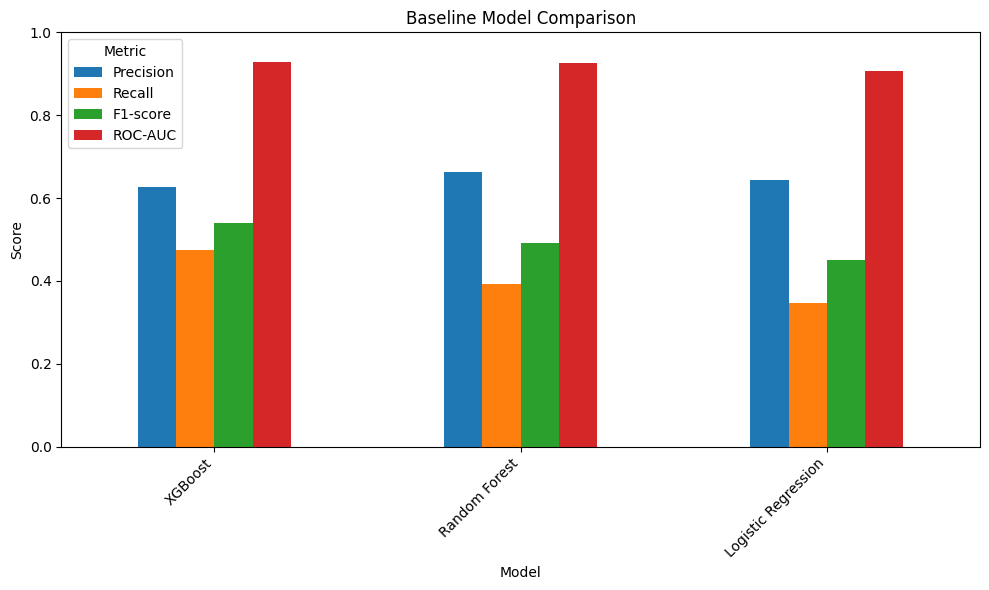

In [8]:
import matplotlib.pyplot as plt

results_plots = results_df.copy()

metrics = ["Precision", "Recall", "F1-score", "ROC-AUC"]

ax = results_plots.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

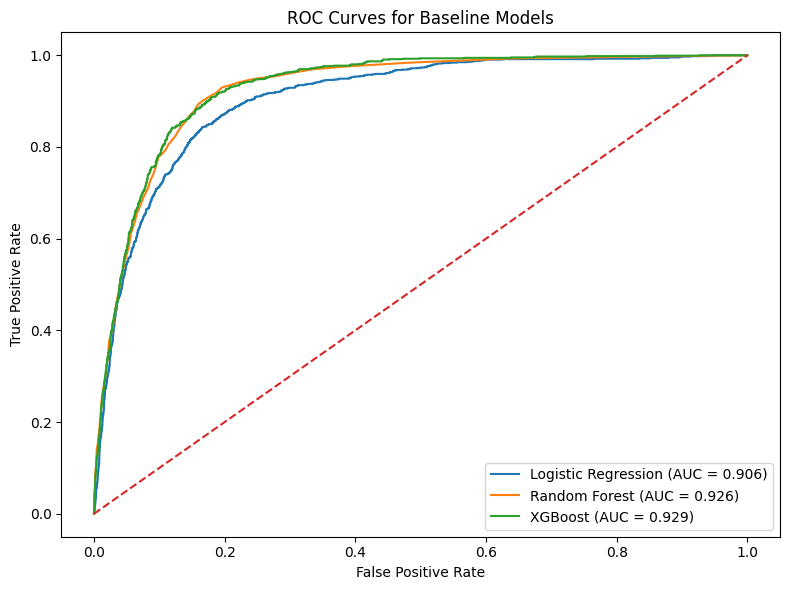

In [9]:
#ROC Curve

model_outputs = {}

for model_name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_final)[:, 1]
    else:
        y_prob = None

    model_outputs[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for model_name, output in model_outputs.items():
    y_prob = output["y_prob"]
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Baseline Models")
plt.legend()
plt.tight_layout()
plt.show()

Random Forest is the most promising
ROC Curve, how well the model separates classes overall

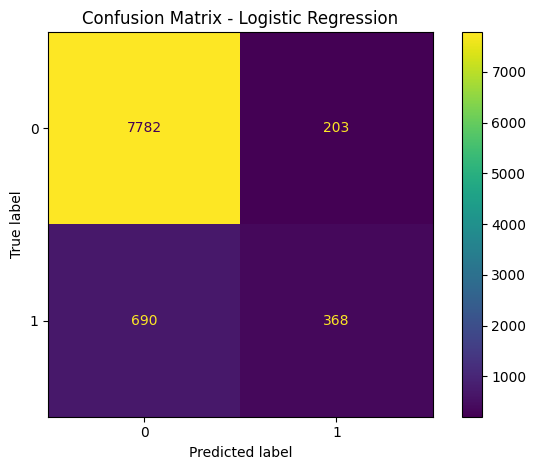

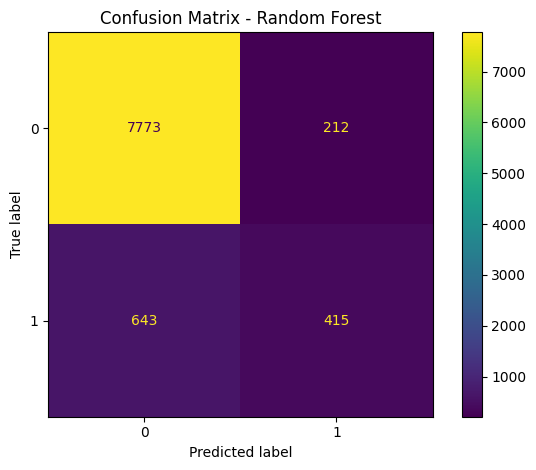

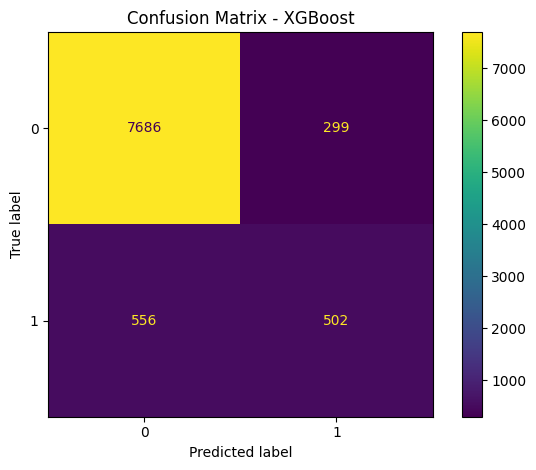

In [12]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

top_models = ["Logistic Regression", "Random Forest", "XGBoost"]

for model_name in top_models:
    y_pred = model_outputs[model_name]["y_pred"]
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

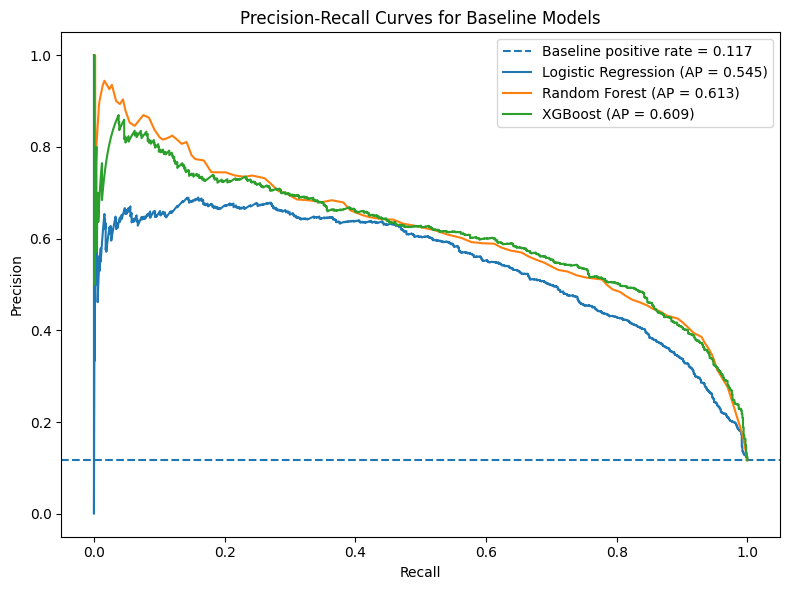

In [13]:
#Plotting a Precision Recall curve so we can see the trade_off or precisions and recall
#How useful the model is for identifying the positvie class

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

model_outputs = {}

for model_name, model in models.items():
    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_final)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_final)
    else:
        y_prob = None

    model_outputs[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

plt.figure(figsize=(8, 6))

positive_rate = y_test.mean()
plt.axhline(
    y=positive_rate,
    linestyle="--",
    label=f"Baseline positive rate = {positive_rate:.3f}"
)

for model_name, output in model_outputs.items():
    y_prob = output["y_prob"]

    if y_prob is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)

        plt.plot(recall, precision, label=f"{model_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Baseline Models")
plt.legend()
plt.tight_layout()
plt.show()

Random Forest stays higher and also has the highest AP, but we can see that XGBoost is competitive